# Real-time Image and Video Sketching using OpenCV

This project focuses on transforming real-world visual content into pencil sketch representations using image processing techniques in Python. The approach is based on grayscale conversion, image inversion, Gaussian blurring, and division-based blending. The system is implemented using OpenCV and is capable of handling static images, real-time webcam feeds, and pre-recorded videos.

Applications of this work span various fields including digital art, creative filters in photography, and real-time visual effects in streaming media. The pipeline is modular and scalable, offering both batch processing and real-time capabilities.

# Requirements

In [5]:
import cv2
import os
import matplotlib.pyplot as plt

# Load & Display Image

Loads an image (car.jpg) from the images/ directory.

Converts it from BGR (OpenCV default) to RGB.

Displays the image using matplotlib.



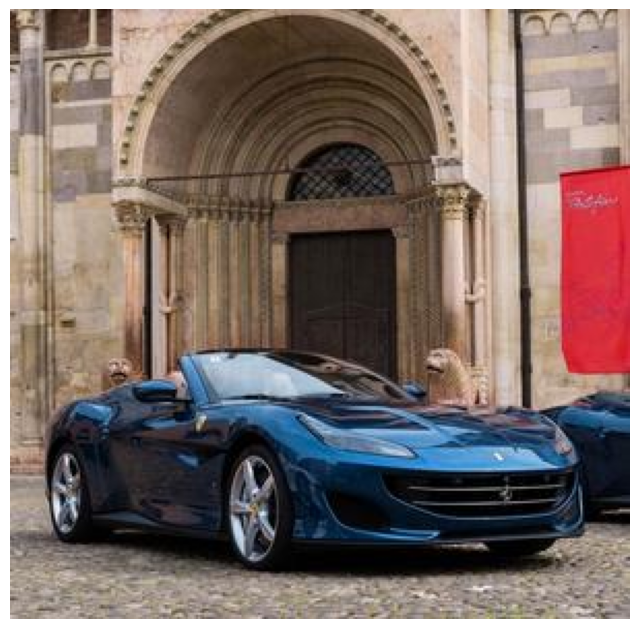

In [6]:
# image address
image_address = os.path.join("images", "car.jpg")

# read the image file
image = cv2.imread(image_address)

# convert channels from BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis('off')
plt.show()

# Creating Sketch

This cell introduces the transformation process that converts the loaded image into a sketch and performs the main sketching process:

1. Converts image to grayscale.
2. Inverts grayscale image.
3. Applies Gaussian blur to smoothen.
4. Inverts the blur.
5. Divides the grayscale image by the inverted blur to create a sketch.
6. Saves and displays the output sketch.

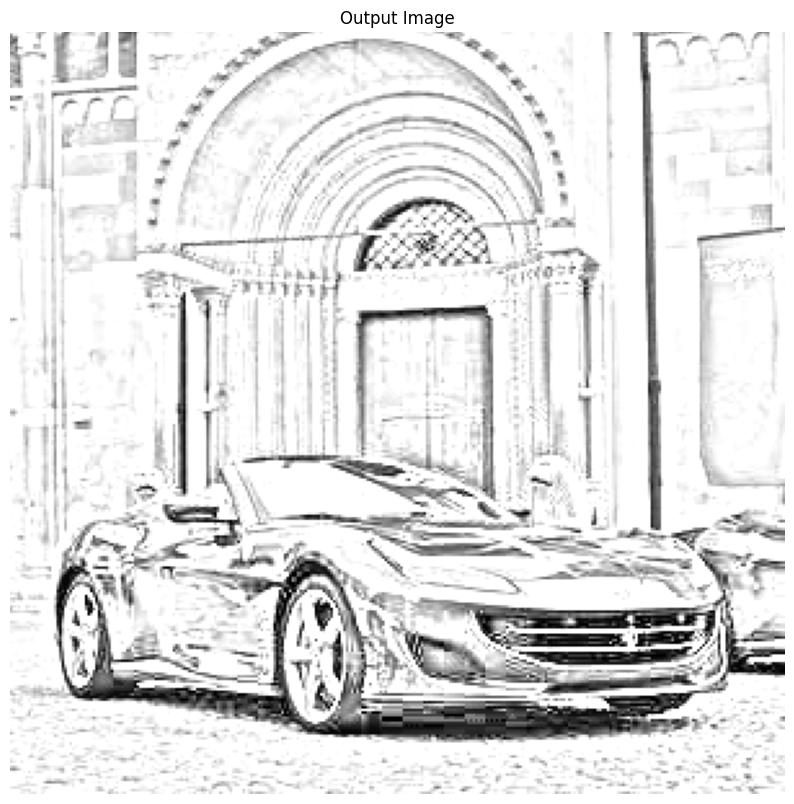

In [ ]:
# Convert the input image from BGR to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Invert the grayscale image (i.e., produce a negative of the grayscale image)
inverted_image = cv2.bitwise_not(gray_image)

# Apply Gaussian blur to the inverted image with a kernel size of 21x21
blur_image = cv2.GaussianBlur(inverted_image, (21,21), 0)

# Invert the blurred image to produce a semi-transparent effect
inverted_blur = cv2.bitwise_not(blur_image)

# Divide the grayscale image by the inverted blurred image to produce the sketch effect
sketch = cv2.divide(gray_image, inverted_blur, scale=256.0)

output_image_path = os.path.join("output", "car_sketch.jpg")
cv2.imwrite(output_image_path, sketch)

# display
plt.figure(figsize=(10, 10))
plt.imshow(sketch, cmap="gray")
plt.title("Output Image")
plt.axis("off")
plt.show()

now we encapsulate the sketching logic into a reusable function sketch_image, enabling processing of any RGB image input.

In [ ]:
def sketch_image(rgb_image):
    
    gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)

    inverted_image = cv2.bitwise_not(gray_image)

    blur_image = cv2.GaussianBlur(inverted_image, (21,21), 0)

    inverted_blur = cv2.bitwise_not(blur_image)

    sketch = cv2.divide(gray_image, inverted_blur, scale=256.0)

    return sketch

# Sketching WebCam Video Stream in Real-time


This section of the notebook implements a system that captures live video from a webcam and applies a pencil-sketch transformation to each frame in real-time. The webcam is accessed through OpenCV's VideoCapture(0), which initializes the default camera on the device. Once the video stream is active, the program retrieves each frame, converts it from the default BGR format to RGB, and then processes it through the sketch_image function defined earlier. This function applies grayscale conversion, image inversion, Gaussian blurring, and pixel-wise division to generate a sketch effect.

After the transformation, each sketch frame is written to an output video file using VideoWriter, which stores the grayscale frames in AVI format. Simultaneously, the sketch is displayed in a live window using cv2.imshow. The loop continues until the user presses the ESC key (ASCII code 27), after which the video stream and file output are properly closed. This component showcases the project’s real-time capabilities and demonstrates how computer vision can be integrated with live camera input for artistic effects or creative filters.

In [ ]:
output_dir = "output"
output_video_path = os.path.join(output_dir, "webcam_sketch.avi")

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    exit()

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
fps = int(fps) if fps > 0 else 10

fourcc = cv2.VideoWriter_fourcc(*"XVID")
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height), isColor=False)
if not out.isOpened():
    cap.release()
    exit()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    sketch = sketch_image(rgb_frame)

    out.write(sketch)
    cv2.imshow(sketch)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
out.release()
cv2.destroyAllWindows()

# Sketching a Video in Real-time


This section extends the sketching functionality to pre-recorded videos, allowing the user to convert an entire video file into a sketched version. The code begins by loading a video from the videos directory using OpenCV's VideoCapture, and verifies whether the file has been opened successfully. It then reads frame-by-frame data, converting each frame to RGB format before applying the same sketch_image transformation used for still images and live video.

The processed sketch frames are written to an output AVI file in grayscale mode using VideoWriter. At the same time, each frame is also displayed in a window labeled "Video Sketch" for real-time monitoring. The loop continues until all frames are processed or the user interrupts it by pressing the ESC key. Once the video ends, both the video reader and writer objects are released, and any remaining windows are closed. This part of the project emphasizes batch video processing and showcases how artistic transformations can be applied non-invasively to multimedia content using simple yet effective image processing techniques.

In [ ]:
video_path = os.path.join("videos", "video.mp4")
output_dir = "output"
output_video_path = os.path.join(output_dir, "video_sketch.avi")

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    exit()

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
fps = int(fps) if fps > 0 else 10

fourcc = cv2.VideoWriter_fourcc(*"XVID")
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height), isColor=False)
if not out.isOpened():
    cap.release()
    exit()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    sketch = sketch_image(rgb_frame)

    out.write(sketch)
    cv2.imshow("Video Sketch", sketch)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
out.release()
cv2.destroyAllWindows()